# Investigating atmospheric temperature and pressure profiles

A reproducible radiosonde case study comparing **Singapore and Ulaanbaatar** on
**7 January and 7 July 2021**, at **00 and 12 UTC**. The same workflow can be used
for other stations by editing `data/soundings.csv` and the parameters below.

## Overview
Explore measured vertical structure, calculate
layer-average temperature lapse rates, and examine the moisture contribution to
pressure-layer thickness. Wind speed provides an additional view of the soundings.

The example is a comparison of individual launches, **not a seasonal climatology**.
Figures and tables below are saved from an executed run; rerun all cells after
changing data. See [README.md](README.md) for environment and dataset preparation.

## Context & methods
The loader preserves blank fields as missing values and checks the input schema
and units. Each analysis selects the fields it needs. This notebook follows the
original report: pressure–height comparisons at both launch times, January
pressure-layer thickness, and temperature, lapse-rate and wind comparisons at 12Z. Lapse rates interpolate in recorded height without
extrapolation; thickness calculations integrate in log pressure.

### Key assumptions
Recorded height is used as supplied, not height above ground. Hydrostatic balance,
a constant dry-air gas constant and constant gravity underpin the model comparisons.
Virtual temperature uses the dilute-water-vapour approximation. Recorded heights
may themselves be hydrostatically derived, so thickness agreement is a consistency
check rather than an independent verification.

Physical reference: [Stull (2017), Practical Meteorology, chapter 1, section 1.8](https://www.eoas.ubc.ca/books/Practical_Meteorology/prmet102/Ch01-atmos-v102b.pdf).

## 1. Setup and parameters
Launch Jupyter from the repository folder. Adjust pressure and height coverage
for your stations. `COMPARISON_TIME_UTC` controls the temperature, lapse-rate and
wind comparisons; both launch times remain in the pressure–height investigation.
`THICKNESS_DATE = None` selects the earliest manifest date for the layer-thickness
investigation. Turn exports off to explore without writing files.

In [1]:
from io import StringIO
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import trapezoid
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "soundings.csv").is_file():
    PROJECT_ROOT = PROJECT_ROOT / "radiosonde-profile-investigation"
if not (PROJECT_ROOT / "data" / "soundings.csv").is_file():
    raise FileNotFoundError("Start Jupyter in the repository folder containing data/soundings.csv.")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
EXPORT_RESULTS = True
REFERENCE_LEVELS_HPA = [1000, 925, 850, 700, 500, 400, 300, 200, 100]
COMPARISON_TIME_UTC = "12Z"
THICKNESS_DATE = None  # None selects the earliest manifest date
LAYER_BOTTOM_HPA, LAYER_TOP_HPA = 850, 500
LAPSE_STEP_M, LAPSE_TOP_M = 1000, 10000
WIND_MIN_HPA, WIND_MAX_HPA = 70, 850
RD, G = 287.053, 9.80665  # J/(kg K), m/s^2
if EXPORT_RESULTS:
    OUTPUT_DIR.mkdir(exist_ok=True)

def save_table(table, name):
    if EXPORT_RESULTS:
        table.to_csv(OUTPUT_DIR / f"{name}.csv")

def show_figure(fig, name):
    if EXPORT_RESULTS:
        fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | "
      f"pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__} | SciPy {scipy.__version__}")

Python 3.13.7 | NumPy 2.4.0 | pandas 3.0.5 | Matplotlib 3.10.8 | SciPy 1.16.3


## 2. Data: schema, loader and manifest
The fixed-width text table has eleven fields, each seven characters wide.
`PRES` is hPa, `TEMP` is degrees Celsius and `SPED` is m/s. The loader rejects
different units; convert values and update the units row together before use.
Missing fields remain `NaN`, with no filling or interpolation at this stage.

In [2]:
SCHEMA = {
    "PRES": ("Pressure", "hPa"),
    "HGHT": ("Height", "m"),
    "TEMP": ("Temperature", "C"),
    "DWPT": ("Dewpoint", "C"),
    "RELH": ("Relative humidity", "%"),
    "MIXR": ("Mixing ratio", "g/kg"),
    "DRCT": ("Wind direction", "deg"),
    "SPED": ("Wind speed", "m/s"),
    "THTA": ("Potential temperature", "K"),
    "THTE": ("Equivalent potential temperature", "K"),
    "THTV": ("Virtual potential temperature", "K"),
}


def read_radiosonde(path: str | Path) -> pd.DataFrame:
    """Read one 11-column, 7-character-wide radiosonde table.

    Return float columns with the original headers and row order. Blank
    fields remain NaN. Reject missing/mismatched headers, unexpected units,
    empty tables and malformed numeric rows. No analysis or filling is done.
    """
    path = Path(path)
    lines = path.read_text(encoding="utf-8-sig").splitlines()
    columns = list(SCHEMA)
    header = next((i for i, line in enumerate(lines)
                   if line.split() == columns), None)
    if header is None:
        raise ValueError(f"{path.name}: expected header {' '.join(columns)}")

    expected_units = [unit for _, unit in SCHEMA.values()]
    if header + 1 >= len(lines) or lines[header + 1].split() != expected_units:
        raise ValueError(f"{path.name}: expected units {expected_units}")

    rows = []
    for line_number, line in enumerate(lines[header + 2:], start=header + 3):
        if not line.strip() or set(line.strip()) == {"-"}:
            continue
        if line[77:].strip():
            raise ValueError(f"{path.name}, line {line_number}: text outside table width")
        # Validate fields individually so malformed text is never silently lost.
        try:
            for start in range(0, 77, 7):
                field = line[start:start + 7].strip()
                if field:
                    float(field)
        except ValueError as exc:
            raise ValueError(f"{path.name}, line {line_number}: invalid numeric field") from exc
        rows.append(line)

    if not rows:
        raise ValueError(f"{path.name}: no observation rows found")

    df = pd.read_fwf(
        StringIO("\n".join(rows)),
        widths=[7] * len(columns),
        names=columns,
        header=None,
        dtype=float,
    )
    df.attrs["source_file"] = str(path)
    df.attrs["units"] = dict(zip(columns, expected_units))
    return df


display(pd.DataFrame.from_dict(SCHEMA, orient="index", columns=["description", "unit"]))

,description,unit
PRES,Pressure,hPa
HGHT,Height,m
TEMP,Temperature,C
DWPT,Dewpoint,C
RELH,Relative humidity,%
MIXR,Mixing ratio,g/kg
DRCT,Wind direction,deg
SPED,Wind speed,m/s
THTA,Potential temperature,K
THTE,Equivalent potential temperature,K


In [3]:
manifest = pd.read_csv(DATA_DIR / "soundings.csv", dtype=str, keep_default_na=False)
required = {"station", "date", "time_utc", "file"}
if not required.issubset(manifest.columns) or manifest.empty:
    raise ValueError(f"Manifest needs at least one row and columns {sorted(required)}.")
if manifest[list(required)].eq("").any().any():
    raise ValueError("Required manifest fields cannot be blank.")
if not manifest["date"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").all():
    raise ValueError("Dates must use YYYY-MM-DD.")
pd.to_datetime(manifest["date"], format="%Y-%m-%d", errors="raise")
if not manifest["time_utc"].isin(["00Z", "12Z"]).all():
    raise ValueError("This comparison supports 00Z and 12Z launches, both UTC.")
if manifest.duplicated(["station", "date", "time_utc"]).any():
    raise ValueError("Each station/date/launch key must be unique.")
soundings, quality_rows = {}, []
for row in manifest.itertuples(index=False):
    path = (DATA_DIR / row.file).resolve()
    if not path.is_relative_to(DATA_DIR.resolve()):
        raise ValueError("Manifest files must be inside data/.")
    key = (row.station, row.date, row.time_utc)
    sounding = read_radiosonde(path)
    soundings[key] = sounding
    quality_rows.append({"station": row.station, "date": row.date, "time_utc": row.time_utc,
                         "rows": len(sounding), "missing_temperature": int(sounding.TEMP.isna().sum()),
                         "missing_wind": int(sounding.SPED.isna().sum()),
                         "min_pressure_hpa": sounding.PRES.min(),
                         "max_pressure_hpa": sounding.PRES.max()})
stations = list(manifest["station"].drop_duplicates())
dates = sorted(manifest["date"].unique())
quality = pd.DataFrame(quality_rows).set_index(["station", "date", "time_utc"])
display(quality)
save_table(quality, "data_quality")

if COMPARISON_TIME_UTC not in {"00Z", "12Z"}:
    raise ValueError("COMPARISON_TIME_UTC must be 00Z or 12Z.")
comparison_soundings = {key: data for key, data in soundings.items() if key[2] == COMPARISON_TIME_UTC}
missing_comparisons = [station for station in stations
                       if not any(key[0] == station for key in comparison_soundings)]
if missing_comparisons:
    raise ValueError(f"No {COMPARISON_TIME_UTC} comparison launch for {missing_comparisons}.")
thickness_date = dates[0] if THICKNESS_DATE is None else THICKNESS_DATE
thickness_inputs = {key: data for key, data in soundings.items() if key[1] == thickness_date}
if not thickness_inputs:
    raise ValueError(f"No launches on THICKNESS_DATE={thickness_date}.")


rows  missing_temperature  missing_wind  \
station     date       time_utc                                            
Singapore   2021-01-07 00Z        120                    0             0   
                       12Z         79                    0             0   
            2021-07-07 00Z        114                    0             1   
                       12Z        138                    0             1   
Ulaanbaatar 2021-01-07 00Z         60                    0             0   
                       12Z         37                    0             0   
            2021-07-07 00Z         63                    0             1   
                       12Z         56                    0             1   

                                 min_pressure_hpa  max_pressure_hpa  
station     date       time_utc                                      
Singapore   2021-01-07 00Z                    5.4            1007.0  
                       12Z                   69.0            1005.0  
            2021-07-07 00Z                    4.6            1007.0  
                       12Z                    3.9            1005.0  
Ulaanbaatar 2021-01-07 00Z                   24.4             876.0  
                       12Z                   36.0             876.0  
            2021-07-07 00Z                   12.7             864.0  
                       12Z                   16.5             861.0

## 3. Analysis 1: pressure and height
Compare January and July with one row per date and one column per station.
Solid blue and dashed orange distinguish 00Z and 12Z launches. The shared scales
show the stations' pressure–height structures without below-surface extrapolation.
The reference table uses exact observed levels; absent levels remain blank rather
than being interpolated. In particular, elevated Ulaanbaatar has no 1000 hPa level.

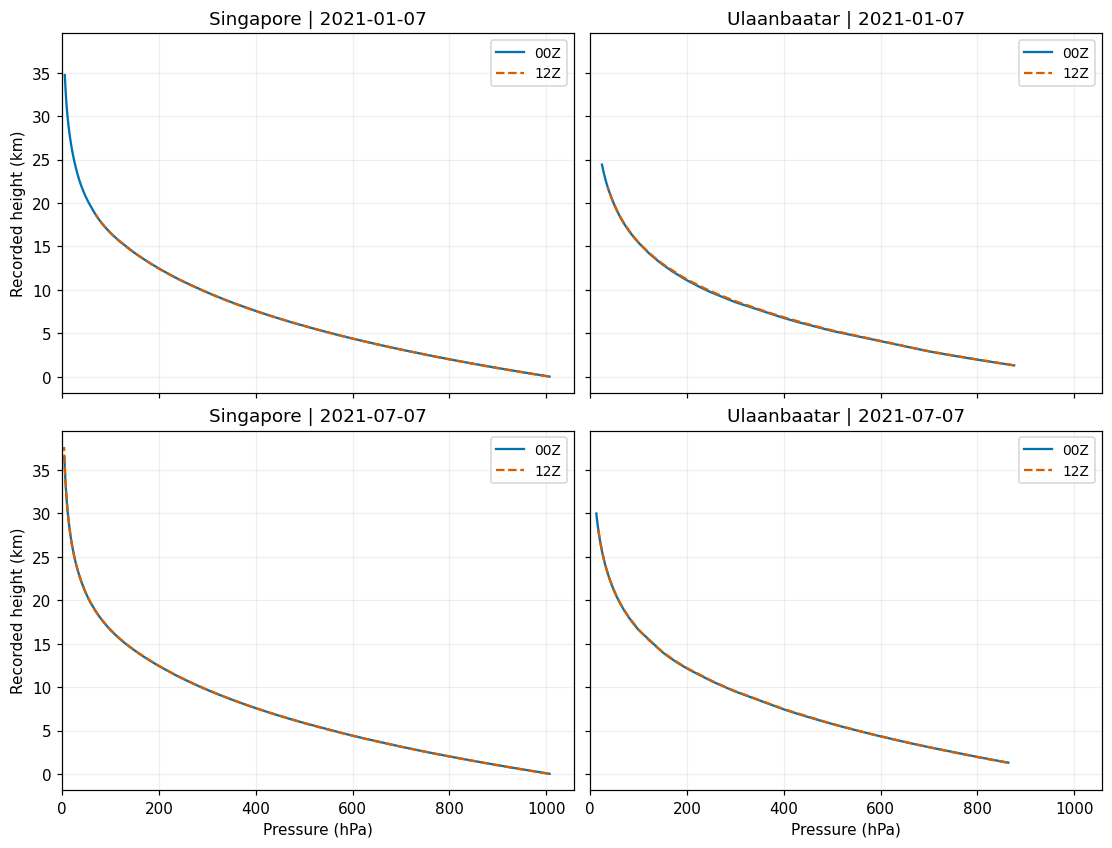

In [4]:
launch_styles = {"00Z": ("#0072B2", "-"), "12Z": ("#D55E00", "--")}

def profile_grid(variable, xlabel, name):
    fig, axes = plt.subplots(len(dates), len(stations),
                             figsize=(5 * len(stations), 3.8 * len(dates)),
                             sharex=True, sharey=True, squeeze=False, layout="constrained")
    for i, date in enumerate(dates):
        for j, station in enumerate(stations):
            ax = axes[i, j]
            for time, (color, style) in launch_styles.items():
                key = (station, date, time)
                if key not in soundings:
                    continue
                data = soundings[key]
                y = data["HGHT"] / 1000 if variable == "PRES" else data["PRES"]
                ax.plot(data[variable], y, color=color, linestyle=style, label=time)
            ax.set_title(f"{station} | {date}")
            if i == len(dates) - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel("Recorded height (km)" if variable == "PRES" else "Pressure (hPa)")
            if ax.lines:
                ax.legend(fontsize=9)
    if variable == "PRES":
        axes[0, 0].set_xlim(left=0)
    else:
        axes[0, 0].invert_yaxis()
    show_figure(fig, name)

profile_grid("PRES", "Pressure (hPa)", "pressure_height_profiles")

In [5]:
reference_profiles = {}
for key, data in soundings.items():
    if data.PRES.duplicated().any():
        raise ValueError(f"{key}: duplicate pressure levels require review.")
    reference_profiles[key] = data.set_index("PRES")["HGHT"].reindex(REFERENCE_LEVELS_HPA)
reference_heights = pd.concat(reference_profiles, axis=1)
reference_heights.columns.names = ["station", "date", "time_utc"]
reference_heights.index.name = "Pressure (hPa)"
display(reference_heights)
save_table(reference_heights, "observed_pressure_level_heights")

station         Singapore                              Ulaanbaatar           \
date           2021-01-07          2021-07-07           2021-01-07            
time_utc              00Z      12Z        00Z      12Z         00Z      12Z   
Pressure (hPa)                                                                
1000                 83.0     68.0       87.0     71.0         NaN      NaN   
925                 764.0    750.0      774.0    761.0         NaN      NaN   
850                1494.0   1482.0     1507.0   1494.0      1525.0   1535.0   
700                3133.0   3127.0     3147.0   3134.0      2918.0   2940.0   
500                5850.0   5850.0     5870.0   5860.0      5270.0   5330.0   
400                7570.0   7570.0     7580.0   7580.0      6760.0   6850.0   
300                9700.0   9690.0     9680.0   9700.0      8580.0   8700.0   
200               12460.0  12440.0    12430.0  12440.0     11100.0  11210.0   
100               16560.0  16540.0    16570.0  16590.0     15421.0  15460.0   

station                             
date           2021-07-07           
time_utc              00Z      12Z  
Pressure (hPa)                      
1000                  NaN      NaN  
925                   NaN      NaN  
850                1449.0   1427.0  
700                3086.0   3086.0  
500                5760.0   5780.0  
400                7440.0   7470.0  
300                9490.0   9530.0  
200               12150.0  12200.0  
100               16590.0  16640.0

### Temperature, moisture and pressure-layer thickness
Investigate the earliest date (January in the example), or `THICKNESS_DATE` if
set explicitly. Use both launch times and all reported levels within the configured
pressure layer. Its two boundaries
must be observed, and height, temperature and mixing ratio must be finite.
This deliberately fails on gaps rather than silently filling moisture data.

Convert temperature to kelvin and mixing ratio $r$ from g/kg to kg/kg, then use
$T_v\approx T(1+0.61r)$. `THTV` is virtual **potential** temperature and is not
substituted for $T_v$. With $x=\ln(p_{bottom}/p)$, trapezoidal integration gives
$D_T=(R_d/g)\int T\,dx$, $D_q=(R_d/g)\int(T_v-T)\,dx$ and $D_v=D_T+D_q$.
Temperatures are weighted by log-pressure thickness, not averaged over rows.

Compare the dry term, moisture increment and recorded layer thickness. This
decomposition holds the measured temperature profile fixed; it does not isolate
every physical cause of station differences. Boundary selection avoids extrapolation
below elevated stations. Rounding, sampling and the approximations can cause discrepancies.

In [6]:
def pressure_layer_diagnostics(sounding, bottom_hpa=850, top_hpa=500):
    """Return layer profiles and hypsometric diagnostics using recorded T and MIXR."""
    if not 0 < top_hpa < bottom_hpa:
        raise ValueError("Require 0 < top pressure < bottom pressure.")
    layer = sounding.loc[sounding["PRES"].between(top_hpa, bottom_hpa),
                         ["PRES", "HGHT", "TEMP", "MIXR"]].copy()
    layer = layer.sort_values("PRES", ascending=False).reset_index(drop=True)
    if not {bottom_hpa, top_hpa}.issubset(set(layer["PRES"])):
        raise ValueError("Both pressure boundaries must be observed.")
    if layer["PRES"].duplicated().any() or not np.isfinite(layer.to_numpy()).all():
        raise ValueError("Layer must have unique pressures and finite measurements.")
    if layer["MIXR"].lt(0).any():
        raise ValueError("Mixing ratio must be nonnegative.")
    layer["T_K"] = layer["TEMP"] + 273.15
    layer["r_kg_kg"] = layer["MIXR"] / 1000
    layer["Tv_K"] = layer["T_K"] * (1 + 0.61 * layer["r_kg_kg"])
    layer["moisture_correction_K"] = layer["Tv_K"] - layer["T_K"]
    x = np.log(bottom_hpa / layer["PRES"].to_numpy())
    rd_over_g = RD / G
    dry_m = rd_over_g * trapezoid(layer["T_K"], x)
    moisture_m = rd_over_g * trapezoid(layer["moisture_correction_K"], x)
    observed_m = layer["HGHT"].iloc[-1] - layer["HGHT"].iloc[0]
    result = {
        "levels_used": len(layer),
        "mean_T_K": trapezoid(layer["T_K"], x) / x[-1],
        "mean_Tv_K": trapezoid(layer["Tv_K"], x) / x[-1],
        "dry_thickness_m": dry_m,
        "moisture_increment_m": moisture_m,
        "predicted_thickness_m": dry_m + moisture_m,
        "observed_thickness_m": observed_m,
        "prediction_minus_observed_m": dry_m + moisture_m - observed_m,
    }
    return layer, result

thickness_rows = []
for key, data in thickness_inputs.items():
    try:
        layer, result = pressure_layer_diagnostics(data, LAYER_BOTTOM_HPA, LAYER_TOP_HPA)
    except ValueError as exc:
        raise ValueError(f"{key}: {exc} Review the configured layer and MIXR coverage.") from exc
    thickness_rows.append(dict(zip(["station", "date", "time_utc"], key)) | result)
thickness = pd.DataFrame(thickness_rows).set_index(["station", "date", "time_utc"])
save_table(thickness, "pressure_layer_thickness")
display(thickness.round(2))

levels_used  mean_T_K  mean_Tv_K  \
station     date       time_utc                                     
Singapore   2021-01-07 00Z                20    279.23     280.71   
                       12Z                20    279.88     281.17   
Ulaanbaatar 2021-01-07 00Z                10    241.27     241.32   
                       12Z                 6    244.30     244.36   

                                 dry_thickness_m  moisture_increment_m  \
station     date       time_utc                                          
Singapore   2021-01-07 00Z               4337.07                 22.95   
                       12Z               4347.14                 19.98   
Ulaanbaatar 2021-01-07 00Z               3747.50                  0.70   
                       12Z               3794.51                  0.97   

                                 predicted_thickness_m  observed_thickness_m  \
station     date       time_utc                                                
Singapore   2021-01-07 00Z                     4360.02                4356.0   
                       12Z                     4367.13                4368.0   
Ulaanbaatar 2021-01-07 00Z                     3748.20                3745.0   
                       12Z                     3795.48                3795.0   

                                 prediction_minus_observed_m  
station     date       time_utc                               
Singapore   2021-01-07 00Z                              4.02  
                       12Z                             -0.87  
Ulaanbaatar 2021-01-07 00Z                              3.20  
                       12Z                              0.48

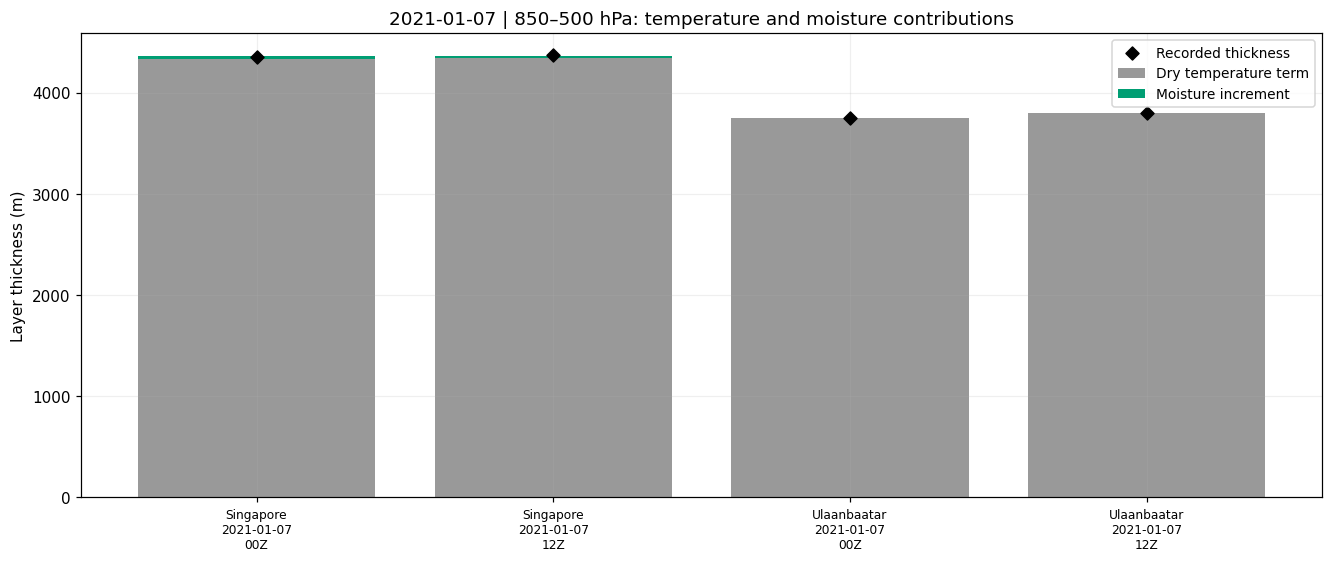

In [7]:
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
position = np.arange(len(thickness))
ax.bar(position, thickness["dry_thickness_m"], color="#999999", label="Dry temperature term")
ax.bar(position, thickness["moisture_increment_m"], bottom=thickness["dry_thickness_m"],
       color="#009E73", label="Moisture increment")
ax.scatter(position, thickness["observed_thickness_m"], color="black", marker="D",
           zorder=3, label="Recorded thickness")
ax.set_xticks(position, ["\n".join(key) for key in thickness.index], fontsize=8)
ax.set(ylabel="Layer thickness (m)", ylim=(0, None),
       title=f"{thickness_date} | {LAYER_BOTTOM_HPA}–{LAYER_TOP_HPA} hPa: temperature and moisture contributions")
ax.legend(fontsize=9)
show_figure(fig, "temperature_moisture_thickness")

## 4. Analyses 2 & 3: temperature at Singapore and Ulaanbaatar
Overlay the January and July profiles at the configured comparison launch time
(12Z in the report). One panel per station and shared axis scales make the
contrast between the stations easy to inspect. Temperature is horizontal;
pressure decreases upwards. The curves use observations without interpolation.
Missing temperatures break the plotted curves. These individual dates do not
establish seasonal averages or identify monsoon or anticyclonic causes.

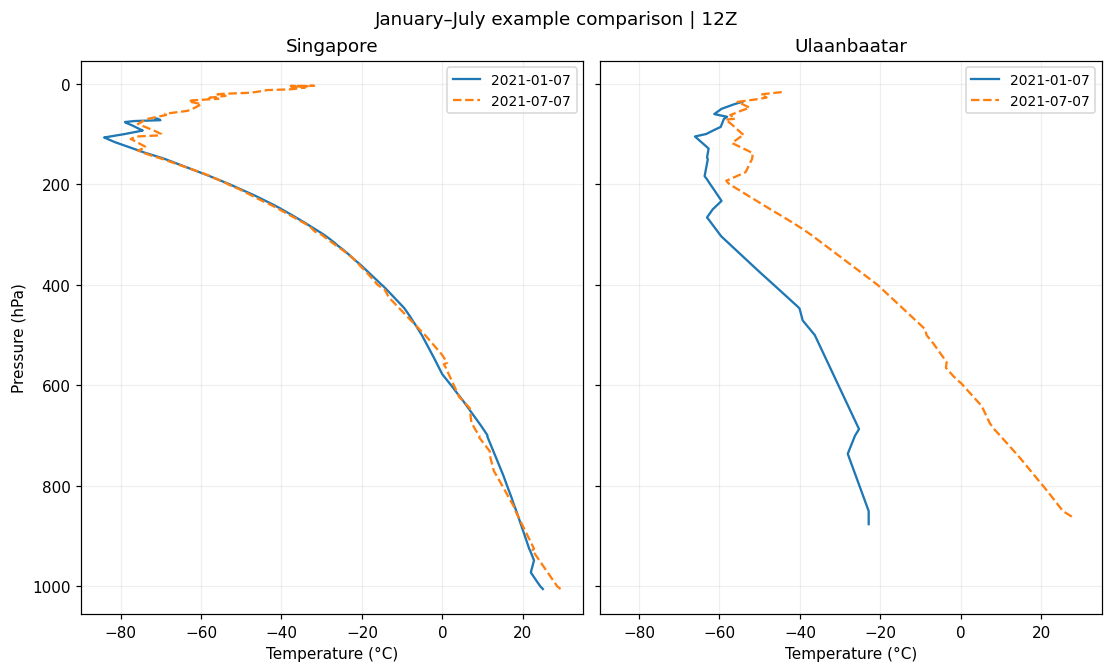

station         Singapore            Ulaanbaatar           
date           2021-01-07 2021-07-07  2021-01-07 2021-07-07
time_utc              12Z        12Z         12Z        12Z
Pressure (hPa)                                             
1000                 24.4       28.6         NaN        NaN
925                  21.6       22.8         NaN        NaN
850                  18.4       18.2       -22.9       25.4
700                  11.2        9.2       -26.3        9.8
500                  -5.1       -4.3       -36.3       -8.5
400                 -15.1      -16.1       -46.5      -20.7
300                 -29.5      -30.1       -59.9      -37.3
200                 -52.9      -53.3       -62.3      -57.5
100                 -78.9      -69.9       -63.3      -54.3

In [8]:
fig, axes = plt.subplots(1, len(stations), figsize=(5 * len(stations), 6),
                         squeeze=False, sharex=True, sharey=True, layout="constrained")
for j, station in enumerate(stations):
    ax = axes[0, j]
    for key, data in comparison_soundings.items():
        if key[0] != station:
            continue
        index = dates.index(key[1])
        profile = data.loc[data.PRES.gt(0), ["PRES", "TEMP"]].sort_values("PRES", ascending=False)
        ax.plot(profile.TEMP, profile.PRES, color=plt.get_cmap("tab10")(index % 10),
                linestyle=["-", "--", "-.", ":"][index % 4], label=key[1])
    ax.set(title=station, xlabel="Temperature (°C)")
    ax.legend(fontsize=9)
axes[0, 0].invert_yaxis()
axes[0, 0].set_ylabel("Pressure (hPa)")
fig.suptitle(f"January–July example comparison | {COMPARISON_TIME_UTC}" if
             set(dates) == {"2021-01-07", "2021-07-07"} else
             f"Temperature profiles | {COMPARISON_TIME_UTC}")
show_figure(fig, "temperature_pressure_comparison")

reference_temperatures = pd.concat({
    key: data.set_index("PRES")["TEMP"].reindex(REFERENCE_LEVELS_HPA)
    for key, data in comparison_soundings.items()
}, axis=1)
reference_temperatures.columns.names = ["station", "date", "time_utc"]
reference_temperatures.index.name = "Pressure (hPa)"
display(reference_temperatures)
save_table(reference_temperatures, "observed_pressure_level_temperatures")

### Temperature and layer-average lapse rates
$\Gamma=-(T_{upper}-T_{lower})/\Delta z$ in °C/km. Positive rates mean cooling
with height; negative rates indicate a layer-average inversion. Temperatures
are linearly interpolated in recorded height; extrapolation is forbidden.

At the configured comparison launch time, use the highest of each station's lowest valid
temperature heights as the shared starting boundary, followed by multiples
of `LAPSE_STEP_M` through `LAPSE_TOP_M`. For the examples this recovers the
16–1000 m Singapore and 1306–2000 m Ulaanbaatar first layers. The station grids
differ because of elevation. Divide the temperature change by the full actual
layer thickness: the first example layers are 0.984 and 0.694 km, respectively. A surface missing temperature can move the
starting boundary upward; the table records the actual boundaries used.

In [9]:
def calculate_layer_lapse_rates(sounding, boundaries_m):
    """Interpolate T in height and return layer averages, without extrapolation."""
    observed = sounding.loc[np.isfinite(sounding[["HGHT", "TEMP"]]).all(axis=1),
                            ["HGHT", "TEMP"]].sort_values("HGHT")
    bounds = np.asarray(boundaries_m, dtype=float)
    if len(bounds) < 2 or not np.isfinite(bounds).all() or not (np.diff(bounds) > 0).all():
        raise ValueError("At least two finite, increasing boundaries are required.")
    if len(observed) < 2 or observed["HGHT"].duplicated().any():
        raise ValueError("At least two unique observed heights are required.")
    if bounds[0] < observed["HGHT"].min() or bounds[-1] > observed["HGHT"].max():
        raise ValueError("Requested boundaries exceed the observed heights; no extrapolation allowed.")
    temperatures = np.interp(bounds, observed["HGHT"], observed["TEMP"])
    thickness_km = np.diff(bounds) / 1000
    return pd.DataFrame({
        "lower_height_m": bounds[:-1],
        "upper_height_m": bounds[1:],
        "lower_temperature_c": temperatures[:-1],
        "upper_temperature_c": temperatures[1:],
        "lapse_rate_c_per_km": -np.diff(temperatures) / thickness_km,
    })

if LAPSE_STEP_M <= 0 or LAPSE_TOP_M <= 0:
    raise ValueError("Lapse step and top height must be positive.")
lapse_details = {}
for station in stations:
    station_profiles = {key: data for key, data in comparison_soundings.items() if key[0] == station}
    start_heights = []
    for key, data in station_profiles.items():
        valid = data.loc[np.isfinite(data[["HGHT", "TEMP"]]).all(axis=1)]
        if len(valid) < 2:
            raise ValueError(f"{key}: too few valid temperature-height observations.")
        start_heights.append(valid["HGHT"].min())
    start = max(start_heights)
    boundaries = np.r_[start, np.arange((np.floor(start / LAPSE_STEP_M) + 1) * LAPSE_STEP_M,
                                        LAPSE_TOP_M + 1, LAPSE_STEP_M)]
    for key, data in station_profiles.items():
        try:
            lapse_details[key] = calculate_layer_lapse_rates(data, boundaries)
        except ValueError as exc:
            raise ValueError(f"{key}: {exc} Review LAPSE_TOP_M and LAPSE_STEP_M.") from exc
lapse_table = pd.concat(lapse_details, names=["station", "date", "time_utc", "layer"])
save_table(lapse_table, "layer_lapse_rate_details")
for key, details in lapse_details.items():
    boundary_table = pd.DataFrame({
        "Altitude (m)": np.r_[details["lower_height_m"].iloc[0], details["upper_height_m"]],
        "Temperature (°C)": np.r_[details["lower_temperature_c"].iloc[0], details["upper_temperature_c"]],
        "Lapse rate (°C/km)": np.r_[np.nan, details["lapse_rate_c_per_km"]],
    })
    print(" | ".join(key))
    display(boundary_table.round(2).fillna("—"))

Singapore | 2021-01-07 | 12Z


,Altitude (m),Temperature (°C),Lapse rate (°C/km)
0,16.0,25.00,—
1,1000.0,20.49,4.58
2,2000.0,16.10,4.39
3,3000.0,11.66,4.44
4,4000.0,5.03,6.63
5,5000.0,-1.36,6.39
6,6000.0,-5.84,4.48
7,7000.0,-11.24,5.4
8,8000.0,-18.03,6.79
9,9000.0,-24.79,6.76


Singapore | 2021-07-07 | 12Z


,Altitude (m),Temperature (°C),Lapse rate (°C/km)
0,16.0,29.40,—
1,1000.0,21.30,8.23
2,2000.0,15.02,6.28
3,3000.0,9.92,5.1
4,4000.0,5.06,4.86
5,5000.0,0.66,4.4
6,6000.0,-5.30,5.96
7,7000.0,-12.44,7.14
8,8000.0,-18.50,6.06
9,9000.0,-24.87,6.38


Ulaanbaatar | 2021-01-07 | 12Z


,Altitude (m),Temperature (°C),Lapse rate (°C/km)
0,1306.0,-22.90,—
1,2000.0,-25.23,3.36
2,3000.0,-25.86,0.62
3,4000.0,-29.81,3.95
4,5000.0,-34.69,4.88
5,6000.0,-39.87,5.18
6,7000.0,-47.72,7.85
7,8000.0,-55.12,7.4
8,9000.0,-61.18,6.06
9,10000.0,-60.83,-0.36


Ulaanbaatar | 2021-07-07 | 12Z


,Altitude (m),Temperature (°C),Lapse rate (°C/km)
0,1306.0,27.60,—
1,2000.0,19.99,10.97
2,3000.0,10.61,9.38
3,4000.0,3.56,7.05
4,5000.0,-3.63,7.19
5,6000.0,-9.15,5.52
6,7000.0,-17.01,7.86
7,8000.0,-24.97,7.96
8,9000.0,-33.03,8.06
9,10000.0,-41.08,8.05


## 5. Additional analysis: wind-speed profiles
At the configured comparison launch time, compare valid nonnegative speeds in the configured common pressure interval.
Zero speeds are valid; missing or invalid speeds break curves. Maxima describe
the selected interval only. Directional shear and causes of the maxima are not
inferred from these speed profiles. Change the range if coverage differs.

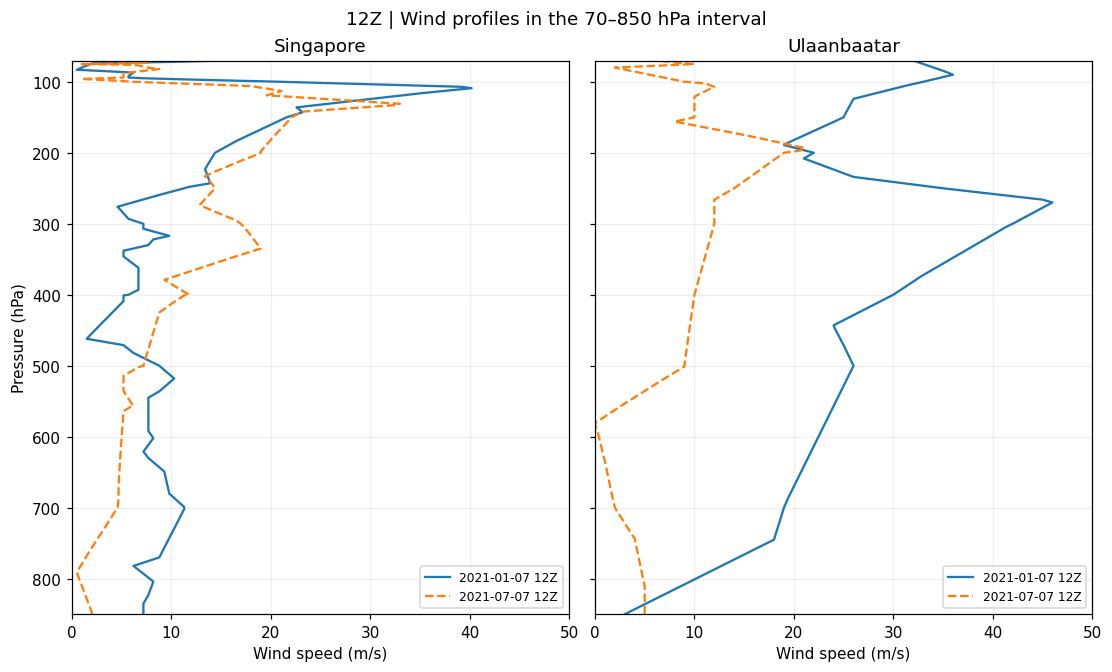

valid_levels  invalid_speed_levels  \
station     date       time_utc                                       
Singapore   2021-01-07 12Z                 69                     0   
            2021-07-07 12Z                 78                     0   
Ulaanbaatar 2021-01-07 12Z                 31                     0   
            2021-07-07 12Z                 38                     0   

                                 peak_speed_m_s  peak_pressure_hpa  
station     date       time_utc                                     
Singapore   2021-01-07 12Z                 40.2              109.0  
            2021-07-07 12Z                 33.0              131.0  
Ulaanbaatar 2021-01-07 12Z                 46.0              270.0  
            2021-07-07 12Z                 21.0              196.0

In [10]:
if not 0 < WIND_MIN_HPA < WIND_MAX_HPA:
    raise ValueError("Wind pressure limits must be positive and increasing.")
wind_rows = []
fig, axes = plt.subplots(1, len(stations), figsize=(5 * len(stations), 6),
                         squeeze=False, sharex=True, sharey=True, layout="constrained")
for j, station in enumerate(stations):
    ax = axes[0, j]
    for i, (key, data) in enumerate(comparison_soundings.items()):
        if key[0] != station:
            continue
        profile = data.loc[data.PRES.between(WIND_MIN_HPA, WIND_MAX_HPA), ["PRES", "SPED"]].copy()
        profile = profile.sort_values("PRES", ascending=False)
        valid = np.isfinite(profile.SPED) & profile.SPED.ge(0)
        profile["speed"] = profile.SPED.where(valid)
        if profile.PRES.duplicated().any() or not valid.any():
            raise ValueError(f"{key}: need unique pressure levels and valid wind speeds in the selected range.")
        peak = profile.loc[profile.speed.idxmax()]
        wind_rows.append(dict(zip(["station", "date", "time_utc"], key)) |
                         {"valid_levels": int(valid.sum()), "invalid_speed_levels": int((~valid).sum()),
                          "peak_speed_m_s": peak.speed, "peak_pressure_hpa": peak.PRES})
        color = plt.get_cmap("tab10")(dates.index(key[1]) % 10)
        ax.plot(profile.speed, profile.PRES, color=color,
                linestyle=["-", "--", "-.", ":"][dates.index(key[1]) % 4], label=f"{key[1]} {key[2]}")
    ax.set(title=station, xlabel="Wind speed (m/s)",
           ylim=(WIND_MAX_HPA, WIND_MIN_HPA))
    ax.legend(fontsize=8)
wind_xmax = max(5.0, 5 * np.ceil(max(row["peak_speed_m_s"] for row in wind_rows) / 5))
axes[0, 0].set_xlim(0, wind_xmax)
axes[0, 0].set_ylabel("Pressure (hPa)")
fig.suptitle(f"{COMPARISON_TIME_UTC} | Wind profiles in the {WIND_MIN_HPA}–{WIND_MAX_HPA} hPa interval")
show_figure(fig, "wind_speed_profiles")
wind_summary = pd.DataFrame(wind_rows).set_index(["station", "date", "time_utc"])
save_table(wind_summary, "wind_speed_summary")
display(wind_summary.round(2))

## 6. Checks and takeaways
Verify that recorded layer thickness is positive, and dry plus moisture thickness equals the virtual-temperature
prediction. These checks support calculation consistency; they cannot recover
missing source metadata or establish that the recorded observations are error-free.

The summary below is calculated from the active dataset and parameters. After
rerunning with another area, interpret its profiles and residuals before drawing
broader conclusions. Use many launches and an explicit sampling design to study
seasonal climate or long-term trends.

In [11]:
assert thickness["observed_thickness_m"].gt(0).all(), "Recorded layer thickness must be positive."
np.testing.assert_allclose(thickness["dry_thickness_m"] + thickness["moisture_increment_m"],
                           thickness["predicted_thickness_m"])
assert np.isfinite(lapse_table["lapse_rate_c_per_km"]).all()
print(f"Processed {len(soundings)} launches at {len(stations)} stations.")
print(f"Temperature, lapse-rate and wind comparisons use {COMPARISON_TIME_UTC}.")
print(f"Layer-average inversions: {int(lapse_table.lapse_rate_c_per_km.lt(0).sum())} "
      f"of {len(lapse_table)} calculated layers.")
print(f"Moisture contribution on {thickness_date}: "
      f"{thickness.moisture_increment_m.min():.1f}–{thickness.moisture_increment_m.max():.1f} m.")

# Report example findings only if the relevant observations are in the active manifest.
example_keys = [(station, "2021-01-07", time)
                for station in ["Singapore", "Ulaanbaatar"] for time in ["00Z", "12Z"]]
if all(key in thickness.index for key in example_keys):
    for time in ["00Z", "12Z"]:
        gap = (thickness.loc[("Singapore", "2021-01-07", time)] -
               thickness.loc[("Ulaanbaatar", "2021-01-07", time)])
        print(f"January {time}: the recorded layer is {gap.observed_thickness_m:.0f} m thicker "
              f"at Singapore; model terms contribute {gap.dry_thickness_m:.0f} m from "
              f"temperature and {gap.moisture_increment_m:.0f} m from moisture.")
print("Consistency checks passed. Individual launches do not establish seasonal averages.")

Processed 8 launches at 2 stations.
Temperature, lapse-rate and wind comparisons use 12Z.
Layer-average inversions: 1 of 38 calculated layers.
Moisture contribution on 2021-01-07: 0.7–22.9 m.
January 00Z: the recorded layer is 611 m thicker at Singapore; model terms contribute 590 m from temperature and 22 m from moisture.
January 12Z: the recorded layer is 573 m thicker at Singapore; model terms contribute 553 m from temperature and 19 m from moisture.
Consistency checks passed. Individual launches do not establish seasonal averages.
